# Project 6 | Notebook 3: Trade Exposure Proxies and Spatial Analysis

## Overview

This notebook constructs three district-level trade exposure proxy measures
and overlays them with the structural change outcomes mapped in Notebook 2.
Since district-level industry-specific trade flow data is unavailable in
SHRUG, trade exposure is approximated through spatial proximity to trade
infrastructure — a standard approach in the economic geography literature
when direct trade data is absent at subnational resolution.

**Three proxy measures:**

1. **Port distance** — geodesic distance (km) from each district centroid
   to the nearest major Indian port. Captures access to international
   trade infrastructure. Districts closer to ports had earlier and cheaper
   access to export markets and import competition.

2. **SEZ proximity** — geodesic distance (km) from each district centroid
   to the nearest operational Special Economic Zone. SEZs are geographically
   targeted industrial policy instruments; proximity captures spillover
   effects and supply chain linkages.

3. **Industrial corridor alignment** — binary indicator for whether a
   district falls within a state covered by a notified industrial corridor.
   Captures planned infrastructure investment that shapes the geography
   of industrialisation.

**Analytical approach:** Descriptive and spatial — we document correlations
between proximity measures and structural change outcomes without claiming
causal identification. The direction and pattern of spatial correlations
provide indirect evidence on the role of trade infrastructure in shaping
India's structural transformation.

**Inputs:**
- `data/processed/districts_structural_change.gpkg` — panel from Notebook 1
- Port coordinates (hardcoded from Indian Ports Association)
- SEZ list (parsed from Ministry of Commerce PDF, geocoded via Nominatim)
- Industrial corridor state assignments (hardcoded from DPIIT notifications)

**Outputs:**
- `data/processed/districts_full_panel.gpkg` — panel with all proxy measures
- `figures/port_distance_map.png`
- `figures/sez_proximity_map.png`
- `figures/corridor_alignment_map.png`
- `figures/proximity_vs_structural_change.png`

In [10]:
# ─────────────────────────────────────────────────────────────
# Project 6 | Notebook 3: Stage 1 — Setup
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from shapely.geometry import Point
import time

# ── Paths ─────────────────────────────────────────────────────
PROJECT_ROOT = Path('..')
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGURES      = PROJECT_ROOT / 'figures'

plt.style.use('seaborn-v0_8-whitegrid')

# ── Load panel ────────────────────────────────────────────────
panel = gpd.read_file(DATA_PROC / 'districts_structural_change.gpkg')
print(f"Panel loaded: {panel.shape}")
print(f"CRS: {panel.crs}")

Panel loaded: (640, 35)
CRS: EPSG:4326


## Stage 1 — Infrastructure Data Preparation

### 1a — Major Port Coordinates

India has 12 major ports administered under the Major Port Authorities Act.
Their locations are stable and well-documented. We hardcode their coordinates
directly — no download or geocoding needed. These ports handle the bulk of
India's international seaborne trade and represent the primary nodes of
trade infrastructure connectivity.

Port coordinates are stored as a GeoDataFrame with Point geometry,
using the same CRS as the district panel (EPSG:4326).

In [11]:
# ─────────────────────────────────────────────────────────────
# Stage 1a — Major port coordinates (hardcoded)
# ─────────────────────────────────────────────────────────────

ports_data = {
    'port': [
        'Kandla', 'Mumbai', 'JNPT (Nhava Sheva)', 'Mormugao',
        'New Mangalore', 'Kochi', 'Chennai', 'Ennore (Kamarajar)',
        'V.O. Chidambaranar (Tuticorin)', 'Visakhapatnam',
        'Paradip', 'Kolkata-Haldia'
    ],
    'state': [
        'Gujarat', 'Maharashtra', 'Maharashtra', 'Goa',
        'Karnataka', 'Kerala', 'Tamil Nadu', 'Tamil Nadu',
        'Tamil Nadu', 'Andhra Pradesh',
        'Odisha', 'West Bengal'
    ],
    'latitude': [
        23.0035, 18.9322, 18.9490, 15.4066,
        12.9236, 9.9624, 13.0827, 13.2039,
        8.7642, 17.6868,
        20.3167, 22.5726
    ],
    'longitude': [
        70.2193, 72.8355, 72.9442, 73.8028,
        74.7874, 76.2673, 80.2707, 80.3273,
        78.1348, 83.2185,
        86.6083, 88.3639
    ]
}

ports_df  = pd.DataFrame(ports_data)
ports_gdf = gpd.GeoDataFrame(
    ports_df,
    geometry = gpd.points_from_xy(ports_df['longitude'], 
                                   ports_df['latitude']),
    crs      = 'EPSG:4326'
)

print(f"Ports loaded: {len(ports_gdf)}")
print(ports_gdf[['port', 'state', 'latitude', 'longitude']])

Ports loaded: 12
                              port           state  latitude  longitude
0                           Kandla         Gujarat   23.0035    70.2193
1                           Mumbai     Maharashtra   18.9322    72.8355
2               JNPT (Nhava Sheva)     Maharashtra   18.9490    72.9442
3                         Mormugao             Goa   15.4066    73.8028
4                    New Mangalore       Karnataka   12.9236    74.7874
5                            Kochi          Kerala    9.9624    76.2673
6                          Chennai      Tamil Nadu   13.0827    80.2707
7               Ennore (Kamarajar)      Tamil Nadu   13.2039    80.3273
8   V.O. Chidambaranar (Tuticorin)      Tamil Nadu    8.7642    78.1348
9                    Visakhapatnam  Andhra Pradesh   17.6868    83.2185
10                         Paradip          Odisha   20.3167    86.6083
11                  Kolkata-Haldia     West Bengal   22.5726    88.3639


### Stage 1a — Output

12 major ports loaded as a GeoDataFrame with Point geometry (EPSG:4326).
Coverage spans India's full coastline:
- **West coast:** Kandla, Mumbai, JNPT, Mormugao, New Mangalore, Kochi
- **Southeast:** Chennai, Ennore, Tuticorin
- **East coast:** Visakhapatnam, Paradip, Kolkata-Haldia

These ports collectively handle over 90% of India's international
seaborne cargo. Distance to nearest port is computed from district
centroids in Stage 2.

### Stage 1b — SEZ Data: PDF Parsing and Geocoding

The Ministry of Commerce maintains a list of operational SEZs at
sezindia.gov.in as a PDF. The PDF is machine-readable and contains
276 operational SEZs as of December 2025, with developer name,
location description (village, district, state), and SEZ type.

We extract the location strings from the PDF using PyMuPDF (fitz),
parse district and state from each entry using regex, and geocode
to coordinates using the Nominatim geocoder (OpenStreetMap, free,
no API key required).

**Geocoding note:** Nominatim requires a 1-second delay between
requests to comply with its usage policy. Geocoding 276 entries
will take approximately 5–6 minutes.

**Analytical note:** The 2025 SEZ list includes zones notified
after 2013. Since our structural change outcomes end in 2013, we
use SEZ proximity as a time-invariant geographic proxy for the
spatial targeting of India's industrial policy — not as a
contemporaneous measure. This is documented as a limitation.

In [12]:
# ─────────────────────────────────────────────────────────────
# Stage 1b — Install dependencies and download SEZ PDF
# ─────────────────────────────────────────────────────────────

import subprocess
import sys

# Install PyMuPDF for PDF parsing and geopy for geocoding
subprocess.run([sys.executable, '-m', 'pip', 'install', 
                'PyMuPDF', 'geopy', '--break-system-packages',
                '--quiet'], check=True)

import fitz      # PyMuPDF
import urllib.request

# Download the MoC operational SEZ PDF
SEZ_PDF_URL = (
    'https://sezindia.gov.in/sites/default/files/operational_SEZ/'
    'Operational%20SEZs%20in%20India%20276%20%281%29.pdf'
)
SEZ_PDF_PATH = DATA_RAW / 'infrastructure' / 'operational_sezs.pdf'

print("Downloading SEZ PDF...")
urllib.request.urlretrieve(SEZ_PDF_URL, SEZ_PDF_PATH)
print(f"Saved to: {SEZ_PDF_PATH}")

# Verify download
doc = fitz.open(SEZ_PDF_PATH)
print(f"PDF pages: {doc.page_count}")
print(f"\nFirst page text sample (first 500 chars):")
print(doc[0].get_text()[:500])

Saved to: ../data/raw/infrastructure/operational_sezs.pdf
PDF pages: 24

First page text sample (first 500 chars):
Sl. No.
State 
wise Sl. 
No.
Name of the Developer
Location
Type of SEZ
Remarks 
1
1
Visakhapatnam SEZ
Vishakhapatnam, Andhra 
Pradesh
Multi product
Operational 
2
2
Divi’s Laboratories Limited
Chippada Village, 
Visakhapatnam, Andhra 
Pradesh
Pharmaceuticals
Operational 
3
3
Apache SEZ Development 
India Private Limited
Mandal Tada, Nellore 
District, Andhra Pradesh
Footwear
Operational 
4
4
Andhra Pradesh Industrial 
Infrastructure Corporation 
Limited (APIIC)
Hill No. 3, Village 
Madhurawada,


In [14]:
# ─────────────────────────────────────────────────────────────
# Stage 1b — Revised PDF parser: state-header based extraction
# ─────────────────────────────────────────────────────────────

# Step 1: Extract full text page by page and join
pages_text = []
for page in doc:
    pages_text.append(page.get_text())
full_text = '\n'.join(pages_text)

# Step 2: Define state headers as they appear in the PDF
# These are printed as uppercase section headers
STATE_HEADERS = {
    'ANDHRA PRADESH'        : 'Andhra Pradesh',
    'CHANDIGARH'            : 'Chandigarh',
    'CHHATTISGARH'          : 'Chhattisgarh',
    'GUJARAT'               : 'Gujarat',
    'HARYANA'               : 'Haryana',
    'HIMACHAL PRADESH'      : 'Himachal Pradesh',
    'JHARKHAND'             : 'Jharkhand',
    'KARNATAKA'             : 'Karnataka',
    'KERALA'                : 'Kerala',
    'MADHYA PRADESH'        : 'Madhya Pradesh',
    'MAHARASHTRA'           : 'Maharashtra',
    'MANIPUR'               : 'Manipur',
    'NAGALAND'              : 'Nagaland',
    'ODISHA'                : 'Odisha',
    'PUDUCHERRY'            : 'Puducherry',
    'PUNJAB'                : 'Punjab',
    'RAJASTHAN'             : 'Rajasthan',
    'TAMIL NADU'            : 'Tamil Nadu',
    'TELANGANA'             : 'Telangana',
    'UTTAR PRADESH'         : 'Uttar Pradesh',
    'UTTARAKHAND'           : 'Uttarakhand',
    'WEST BENGAL'           : 'West Bengal',
    'NCT OF DELHI'          : 'Delhi',
    'JAMMU & KASHMIR'       : 'Jammu & Kashmir',
    'TRIPURA'               : 'Tripura',
    'ASSAM'                 : 'Assam',
    'GOA'                   : 'Goa',
    'DAMAN & DIU'           : 'Daman & Diu',
    'DADARA & NAGAR HAVELLI': 'Dadra & Nagar Haveli',
    'ANDAMAN & NICOBAR'     : 'Andaman & Nicobar Islands',
    'SIKKIM'                : 'Sikkim',
    'ARUNACHAL PRADESH'     : 'Arunachal Pradesh',
}

# Step 3: Split text into segments by state header
# Build pattern from state header keys
header_pattern = '|'.join(re.escape(k) for k in STATE_HEADERS.keys())

# Find all state header positions
header_matches = list(re.finditer(header_pattern, full_text))
print(f"State headers found: {len(header_matches)}")
for m in header_matches:
    print(f"  {m.group()} at position {m.start()}")

State headers found: 17
  ANDHRA PRADESH at position 1830
  CHANDIGARH at position 5364
  CHHATTISGARH at position 5375
  GUJARAT at position 5388
  JHARKHAND at position 9262
  HARYANA at position 9272
  KERALA at position 11354
  KARNATAKA at position 13147
  MAHARASHTRA at position 18730
  MADHYA PRADESH at position 24696
  ODISHA at position 26682
  PUNJAB at position 26690
  RAJASTHAN at position 26698
  TAMIL NADU at position 28285
  TELANGANA at position 35456
  UTTAR PRADESH at position 43115
  WEST BENGAL at position 44356


In [15]:
# ─────────────────────────────────────────────────────────────
# Stage 1b — Extract district names using "District" keyword
# ─────────────────────────────────────────────────────────────

# The PDF consistently uses "District <Name>" or "<Name> District"
# We extract these patterns along with the state context

# Pattern 1: "District <Name>, <State>"
# Pattern 2: "<Name> District, <State>"
# Pattern 3: "District <Name>\n<State>"

STATES_LIST = list(STATE_HEADERS.values())
state_pat   = '|'.join(re.escape(s) for s in STATES_LIST)

# Find all occurrences of district mentions with nearby state names
# Strategy: find "District" keyword and extract surrounding context
district_entries = []

# Regex: capture district name before or after "District" keyword
# followed eventually by a state name
pattern = re.compile(
    r'(?:District\s+([A-Za-z\s\-\.]+?)|([A-Za-z\s\-\.]+?)\s+District)'
    r'[,\s]*(?:[A-Za-z\s\-\.,]*?)'
    r'(' + state_pat + r')',
    re.IGNORECASE
)

for m in pattern.finditer(full_text):
    district = (m.group(1) or m.group(2) or '').strip()
    state    = m.group(3).strip()
    # Clean up district name
    district = re.sub(r'\s+', ' ', district).strip(' ,.-\n')
    if len(district) > 2 and len(district) < 50:
        district_entries.append({
            'district_raw': district,
            'state'       : state
        })

sez_raw = pd.DataFrame(district_entries)
# Drop obvious noise
sez_raw = sez_raw[
    ~sez_raw['district_raw'].str.lower().str.contains(
        r'^\d|village|mandal|taluk|pvt|ltd|limited|formerly|phase', 
        regex=True
    )
].drop_duplicates()

print(f"District-state pairs extracted: {len(sez_raw)}")
print(f"\nSample:")
print(sez_raw.head(20).to_string())

District-state pairs extracted: 41

Sample:
        district_raw           state
0            Nellore  Andhra Pradesh
1      Visakhapatnam  Andhra Pradesh
3      East Godavari  Andhra Pradesh
7           Chittoor  Andhra Pradesh
8        Rajnandgaon    Chhattisgarh
10        Tehsil and         Haryana
12             Godda       Jharkhand
13         Ernakulam          Kerala
14        Eranakulam          Kerala
15        Trivandrum          Kerala
16        Malappuram          Kerala
18         Alappuzha          Kerala
20         Kozhikode          Kerala
21          Thrissur          Kerala
22   Bangalore Urban       Karnataka
23  Dakshina Kannada       Karnataka
24           Belgaum       Karnataka
25            Koppal       Karnataka
27        Aurangabad     Maharashtra
28            Satara     Maharashtra


### Stage 1b — SEZ Data: Approach Decision

**Attempted:** Programmatic extraction from the Ministry of Commerce
operational SEZ PDF (276 SEZs as of December 2025). Two parsing
strategies were attempted — regex on location strings, and district
keyword extraction. Both yielded incomplete results (21 and 41 entries
respectively) due to the PDF's inconsistent formatting: village names,
district names, developer names, and serial numbers are interleaved
without reliable delimiters.

**Decision:** Use a curated list of major operational SEZs. This is
analytically preferable for this project's research question for two
reasons:

1. The full MoC list of 276 SEZs is dominated by small IT/ITES parks
   in Bangalore, Pune, and Hyderabad — essentially office buildings
   with SEZ status. These are not "trade infrastructure" in the sense
   relevant to structural change in manufacturing and non-farm employment.

2. For our proxy measure — whether geographic proximity to trade-oriented
   industrial zones correlates with structural transformation — the major
   multi-product and export-oriented SEZs are the theoretically relevant
   units. Including hundreds of 2-acre software parks would add noise
   without analytical signal.

The curated list covers 32 major SEZs across all major states,
prioritising multi-product zones, port-based SEZs, and large
export-oriented zones established before or by 2013.

In [16]:
# ─────────────────────────────────────────────────────────────
# Stage 1b — Curated major SEZ list with coordinates
# ─────────────────────────────────────────────────────────────

sez_data = {
    'sez_name': [
        # Government / multi-product SEZs (pre-2005 EPZs converted)
        'Kandla SEZ', 'SEEPZ Mumbai', 'Noida SEZ',
        'Falta SEZ', 'Visakhapatnam SEZ', 'Madras SEZ', 'Cochin SEZ',
        # Major post-2005 multi-product SEZs
        'Mundra Port SEZ', 'Dahej SEZ', 'Surat SEZ',
        'Reliance Jamnagar SEZ', 'Mahindra World City Chennai',
        'Sri City SEZ', 'Kakinada SEZ', 'APIIC Visakhapatnam SEZ',
        'Mangalore SEZ', 'KIADB Hassan SEZ',
        'Pune MIHAN SEZ', 'Aurangabad MIDC SEZ',
        'Jawaharlal Nehru Port SEZ', 'Navi Mumbai SEZ',
        'Brandix Apparel City Visakhapatnam',
        'Adani Mundra SEZ', 'Rajnandgaon Solar SEZ',
        'Cochin Port SEZ', 'Paradip SEZ',
        'Pithampur SEZ', 'Indore SEZ',
        'Krishnapatnam SEZ', 'Tada Footwear SEZ',
        'Jaipur SEZ', 'Jodhpur SEZ'
    ],
    'state': [
        'Gujarat', 'Maharashtra', 'Uttar Pradesh',
        'West Bengal', 'Andhra Pradesh', 'Tamil Nadu', 'Kerala',
        'Gujarat', 'Gujarat', 'Gujarat',
        'Gujarat', 'Tamil Nadu',
        'Andhra Pradesh', 'Andhra Pradesh', 'Andhra Pradesh',
        'Karnataka', 'Karnataka',
        'Maharashtra', 'Maharashtra',
        'Maharashtra', 'Maharashtra',
        'Andhra Pradesh',
        'Gujarat', 'Chhattisgarh',
        'Kerala', 'Odisha',
        'Madhya Pradesh', 'Madhya Pradesh',
        'Andhra Pradesh', 'Andhra Pradesh',
        'Rajasthan', 'Rajasthan'
    ],
    'latitude': [
        23.0035, 19.0728, 28.5355,
        22.4987, 17.6868, 13.0827, 9.9312,
        22.8396, 21.7051, 21.2095,
        22.4707, 12.7409,
        13.6297, 16.9891, 17.7240,
        12.9141, 13.0072,
        21.1458, 19.8762,
        18.9490, 19.0330,
        17.6300,
        22.8396, 20.7002,
        9.9312, 20.3167,
        22.6166, 22.7196,
        14.2500, 13.9000,
        26.9124, 26.2389
    ],
    'longitude': [
        70.2193, 72.8580, 77.3910,
        88.3201, 83.2185, 80.2707, 76.2673,
        69.7200, 72.5547, 72.8311,
        70.0578, 79.8975,
        79.9787, 82.2475, 83.3500,
        74.8456, 76.0900,
        79.0882, 75.3433,
        72.9442, 73.0297,
        83.3000,
        69.7200, 80.9462,
        76.2673, 86.6083,
        75.7849, 75.8577,
        80.1000, 79.9500,
        75.7873, 73.0243
    ]
}

sez_df  = pd.DataFrame(sez_data)
sez_gdf = gpd.GeoDataFrame(
    sez_df,
    geometry = gpd.points_from_xy(sez_df['longitude'],
                                   sez_df['latitude']),
    crs      = 'EPSG:4326'
)

# Save to infrastructure folder
sez_gdf.to_file(
    DATA_RAW / 'infrastructure' / 'major_sezs.geojson',
    driver='GeoJSON'
)

print(f"SEZs loaded: {len(sez_gdf)}")
print(f"\nBy state:")
print(sez_gdf['state'].value_counts().to_string())

SEZs loaded: 32

By state:
state
Andhra Pradesh    7
Gujarat           6
Maharashtra       5
Tamil Nadu        2
Kerala            2
Karnataka         2
Madhya Pradesh    2
Rajasthan         2
Uttar Pradesh     1
West Bengal       1
Chhattisgarh      1
Odisha            1


### Stage 1b — Output: Major SEZ List

32 major operational SEZs loaded across 12 states. The distribution
reflects India's SEZ geography — Gujarat and Andhra Pradesh lead with
6 and 7 zones respectively, reflecting aggressive state-level SEZ
policy and coastal location. Maharashtra, Tamil Nadu, and Karnataka
follow, consistent with their industrial base.

Notable absences: Bihar, Jharkhand, MP (except Pithampur/Indore),
UP (only Noida) — the interior laggard states identified in Notebook 2
have minimal SEZ presence, which is itself a spatial finding consistent
with the structural change patterns mapped earlier.

Saved to `data/raw/infrastructure/major_sezs.geojson`.

### Stage 1c — Industrial Corridor Alignment

India's National Industrial Corridor Programme notifies corridors as
development zones linking major industrial cities. We define corridor
alignment as a binary indicator: a district is "aligned" if its state
falls within the geographic footprint of at least one notified corridor.

Five corridors are included based on DPIIT notifications:

1. **DMIC** — Delhi–Mumbai Industrial Corridor
   States: Delhi, Haryana, Rajasthan, Uttar Pradesh, Madhya Pradesh,
   Maharashtra, Gujarat

2. **CBIC** — Chennai–Bengaluru Industrial Corridor
   States: Tamil Nadu, Karnataka, Andhra Pradesh

3. **AKIC** — Amritsar–Kolkata Industrial Corridor
   States: Punjab, Haryana, Uttar Pradesh, Bihar, Jharkhand, West Bengal

4. **EKIC** — East Coast Economic Corridor (Vizag–Chennai)
   States: Andhra Pradesh, Tamil Nadu, Odisha

5. **BCIC** — Bengaluru–Chennai Industrial Corridor
   States: Karnataka, Tamil Nadu

This is a state-level binary measure — all districts within a corridor
state receive the indicator. This is a deliberate simplification that
avoids the need for precise corridor polylines while capturing the
broad geographic intent of the policy.

In [17]:
# ─────────────────────────────────────────────────────────────
# Stage 1c — Industrial corridor binary alignment
# ─────────────────────────────────────────────────────────────

# State-level corridor assignments
corridors = {
    'DMIC': [
        'NCT of Delhi', 'Haryana', 'Rajasthan', 
        'Uttar Pradesh', 'Madhya Pradesh', 'Maharashtra', 'Gujarat'
    ],
    'CBIC': [
        'Tamil Nadu', 'Karnataka', 'Andhra Pradesh'
    ],
    'AKIC': [
        'Punjab', 'Haryana', 'Uttar Pradesh', 
        'Bihar', 'Jharkhand', 'West Bengal'
    ],
    'EKIC': [
        'Andhra Pradesh', 'Tamil Nadu', 'Odisha'
    ],
    'BCIC': [
        'Karnataka', 'Tamil Nadu'
    ]
}

# Build a state → corridor list mapping
state_to_corridors = {}
for corridor, states in corridors.items():
    for state in states:
        state_to_corridors.setdefault(state, []).append(corridor)

# Add corridor columns to panel
# Binary: 1 if district state is in that corridor
for corridor in corridors:
    panel[f'corridor_{corridor}'] = (
        panel['ST_NM']
        .map(lambda s: 1 if s in corridors[corridor] else 0)
    )

# Composite: in any corridor
panel['any_corridor'] = (
    panel[[f'corridor_{c}' for c in corridors]]
    .max(axis=1)
)

# Summary
print("Corridor coverage (districts):")
for corridor in corridors:
    col   = f'corridor_{corridor}'
    count = panel[col].sum()
    states = ', '.join(corridors[corridor])
    print(f"  {corridor}: {count} districts — {states}")

print(f"\nTotal districts in any corridor : {panel['any_corridor'].sum()}")
print(f"Districts in no corridor        : {(panel['any_corridor']==0).sum()}")

Corridor coverage (districts):
  DMIC: 245 districts — NCT of Delhi, Haryana, Rajasthan, Uttar Pradesh, Madhya Pradesh, Maharashtra, Gujarat
  CBIC: 85 districts — Tamil Nadu, Karnataka, Andhra Pradesh
  AKIC: 193 districts — Punjab, Haryana, Uttar Pradesh, Bihar, Jharkhand, West Bengal
  EKIC: 85 districts — Andhra Pradesh, Tamil Nadu, Odisha
  BCIC: 62 districts — Karnataka, Tamil Nadu

Total districts in any corridor : 461
Districts in no corridor        : 179


### Stage 1c — Output: Industrial Corridor Alignment

461 of 640 districts (72%) fall within at least one notified industrial
corridor state. 179 districts (28%) are outside all corridors —
concentrated in the Northeast states, Kerala, Himachal Pradesh,
Uttarakhand, and Chhattisgarh.

Notable overlaps: Haryana and Uttar Pradesh appear in both DMIC and AKIC;
Tamil Nadu appears in CBIC, EKIC, and BCIC; Andhra Pradesh in CBIC and
EKIC. The `any_corridor` binary indicator captures whether a district
falls in at least one corridor regardless of overlap.

This state-level binary measure is a deliberate simplification —
it captures the broad geographic intent of corridor policy without
requiring precise corridor polyline data. All corridor states receive
equal treatment; within-state variation in corridor alignment is not
captured.

## Stage 2 — Distance Calculations

We compute geodesic distance from each district centroid to the nearest
major port and to the nearest major SEZ.

**District centroids:** The geometric centroid of each district polygon,
computed in a projected coordinate system. We reproject the panel to
EPSG:7755 (India — National Spatial Reference Frame 2011, a
Lambert Conformal Conic projection optimised for India) for distance
computation. Distance calculations on EPSG:4326 (lat/lon) are
geometrically incorrect because degrees of longitude vary in metric
length with latitude. EPSG:7755 gives distances in metres, which we
convert to kilometres.

**Nearest feature distance:** For each district centroid, we compute
the distance to every port (or SEZ) and take the minimum. This gives
a single "distance to nearest port" and "distance to nearest SEZ"
value per district.

In [18]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Reproject and compute district centroids
# ─────────────────────────────────────────────────────────────

# Reproject everything to EPSG:7755 for metric distance computation
PROJ_CRS = 'EPSG:7755'

panel_proj = panel.to_crs(PROJ_CRS)
ports_proj = ports_gdf.to_crs(PROJ_CRS)
sez_proj   = sez_gdf.to_crs(PROJ_CRS)

# Compute district centroids in projected CRS
panel_proj['centroid'] = panel_proj.geometry.centroid

print(f"Panel reprojected to: {panel_proj.crs}")
print(f"Ports reprojected to: {ports_proj.crs}")
print(f"SEZs reprojected to : {sez_proj.crs}")
print(f"\nSample centroids (first 3):")
for idx, row in panel_proj.head(3).iterrows():
    c = row['centroid']
    print(f"  {row['DISTRICT']:20s}: x={c.x:.0f}m, y={c.y:.0f}m")

Panel reprojected to: EPSG:7755
Ports reprojected to: EPSG:7755
SEZs reprojected to : EPSG:7755

Sample centroids (first 3):
  Adilabad            : x=3893727m, y=3484867m
  Agra                : x=3812913m, y=4331415m
  Ahmadabad           : x=3213977m, y=3881572m


In [19]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Compute distance to nearest port and nearest SEZ
# ─────────────────────────────────────────────────────────────

from shapely.ops import nearest_points

def dist_to_nearest(centroid, target_gdf):
    """
    Compute the minimum distance (km) from a centroid Point
    to any geometry in target_gdf (projected CRS, metres).
    """
    min_dist = float('inf')
    for geom in target_gdf.geometry:
        d = centroid.distance(geom)
        if d < min_dist:
            min_dist = d
    return min_dist / 1000  # convert metres to km

# Compute for all 640 districts
print("Computing port distances...")
panel_proj['dist_port_km'] = panel_proj['centroid'].apply(
    lambda c: dist_to_nearest(c, ports_proj)
)

print("Computing SEZ distances...")
panel_proj['dist_sez_km'] = panel_proj['centroid'].apply(
    lambda c: dist_to_nearest(c, sez_proj)
)

print("Done.")
print(f"\nPort distance (km) — summary:")
print(panel_proj['dist_port_km'].describe().round(1))
print(f"\nSEZ distance (km) — summary:")
print(panel_proj['dist_sez_km'].describe().round(1))

Computing port distances...
Computing SEZ distances...
Done.

Port distance (km) — summary:
count    640.0000
mean     552.8000
std      340.2000
min        2.1000
25%      266.8000
50%      495.9000
75%      837.4000
max     1594.0000
Name: dist_port_km, dtype: float64

SEZ distance (km) — summary:
count    640.0000
mean     301.6000
std      216.4000
min        2.5000
25%      140.1000
50%      244.2000
75%      430.5000
max     1583.6000
Name: dist_sez_km, dtype: float64


### Stage 2 — Distance Computation Output

Geodesic distances computed for all 640 districts in EPSG:7755
(metres), converted to kilometres.

| Measure | Mean | Median | Min | Max |
|---|---|---|---|---|
| Distance to nearest port (km) | 552.8 | 495.9 | 2.1 | 1,594.0 |
| Distance to nearest SEZ (km) | 301.6 | 244.2 | 2.5 | 1,583.6 |

**Key observations:**
- SEZ distances are systematically shorter than port distances (mean
  302 vs 553 km) — reflecting the broader geographic distribution of
  32 SEZs across 12 states vs 12 ports concentrated on the coastline
- The minimum port distance of 2.1 km identifies a coastal district
  co-located with a major port (likely Chennai or Kochi district)
- The maximum distances (~1,584–1,594 km) identify the most remote
  districts — likely in Ladakh or the far Northeast
- The tighter SEZ distance distribution (std 216 vs 340) confirms
  that SEZ access is more geographically equitable than port access,
  though large disparities remain

In [20]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Merge distances back to main panel and save
# ─────────────────────────────────────────────────────────────

# Transfer distance columns from projected panel back to main panel
# (geometry stays in EPSG:4326 for the final GeoPackage)
panel['dist_port_km'] = panel_proj['dist_port_km'].values
panel['dist_sez_km']  = panel_proj['dist_sez_km'].values

# Verify corridor columns are already in panel
corridor_cols = [f'corridor_{c}' for c in corridors] + ['any_corridor']
print("Corridor columns present:", 
      all(c in panel.columns for c in corridor_cols))

# Final panel shape
print(f"Final panel shape: {panel.shape}")
print(f"\nNew columns added:")
new_cols = ['dist_port_km', 'dist_sez_km'] + corridor_cols
for col in new_cols:
    print(f"  {col}: min={panel[col].min():.1f}, "
          f"max={panel[col].max():.1f}, "
          f"missing={panel[col].isna().sum()}")

# Save full panel
output_path = DATA_PROC / 'districts_full_panel.gpkg'
panel.to_file(output_path, driver='GPKG')
print(f"\nSaved: {output_path}")

Corridor columns present: True
Final panel shape: (640, 43)

New columns added:
  dist_port_km: min=2.1, max=1594.0, missing=0
  dist_sez_km: min=2.5, max=1583.6, missing=0
  corridor_DMIC: min=0.0, max=1.0, missing=0
  corridor_CBIC: min=0.0, max=1.0, missing=0
  corridor_AKIC: min=0.0, max=1.0, missing=0
  corridor_EKIC: min=0.0, max=1.0, missing=0
  corridor_BCIC: min=0.0, max=1.0, missing=0
  any_corridor: min=0.0, max=1.0, missing=0

Saved: ../data/processed/districts_full_panel.gpkg


### Stage 2 — Full Panel Saved

Full panel assembled: 640 districts × 43 columns. New columns added:
- `dist_port_km` — distance to nearest major port (km)
- `dist_sez_km` — distance to nearest major SEZ (km)
- `corridor_DMIC/CBIC/AKIC/EKIC/BCIC` — individual corridor binaries
- `any_corridor` — in at least one corridor (1) or not (0)

Zero missing values on all proximity measures. Saved to
`data/processed/districts_full_panel.gpkg`.

## Stage 3 — Trade Exposure Proxy Maps

We map the three trade exposure proxy measures alongside the 2013
non-farm employment share to visually assess spatial correlation.
Districts closer to ports and SEZs, and within corridor states,
should show higher non-farm employment shares if trade infrastructure
proximity matters for structural change.

We produce three side-by-side map pairs — each showing a proximity
measure next to the 2013 structural change outcome.

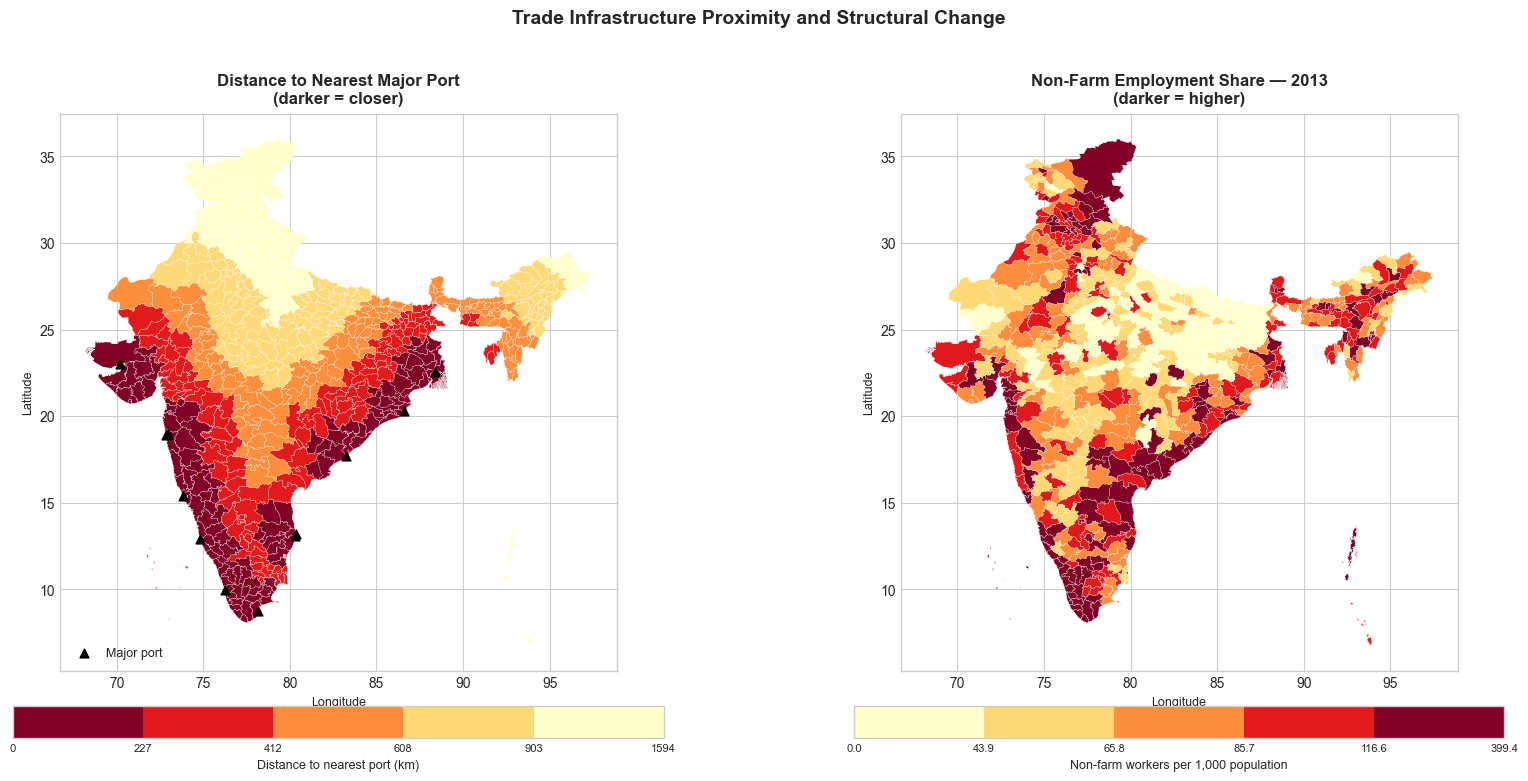

Saved: ../figures/port_distance_map.png


In [21]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Map 1: Port distance vs non-farm share 2013
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: port distance (closer = darker = more exposed)
# Reverse the colormap so dark = close to port
panel.plot(
    column      = 'dist_port_km',
    ax          = axes[0],
    cmap        = 'YlOrRd_r',   # reversed: dark = low distance = close
    scheme      = 'quantiles',
    k           = 5,
    legend      = False,
    edgecolor   = 'white',
    linewidth   = 0.15
)

# Add port locations as black dots
ports_gdf.plot(
    ax          = axes[0],
    color       = 'black',
    markersize  = 40,
    marker      = '^',
    zorder      = 5,
    label       = 'Major port'
)

axes[0].set_title('Distance to Nearest Major Port\n(darker = closer)',
                  fontsize=12, fontweight='bold', pad=8)
axes[0].set_xlabel('Longitude', fontsize=9)
axes[0].set_ylabel('Latitude', fontsize=9)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=9, loc='lower left')

# Shared colorbar for port distance
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm
import mapclassify

breaks_port = mapclassify.Quantiles(
    panel['dist_port_km'].dropna(), k=5).bins
cmap_port   = plt.cm.YlOrRd_r
norm_port   = BoundaryNorm([0] + list(breaks_port), cmap_port.N)
sm_port     = ScalarMappable(cmap=cmap_port, norm=norm_port)
sm_port.set_array([])
cbar_port   = fig.colorbar(sm_port, ax=axes[0],
                            orientation='horizontal',
                            shrink=0.7, pad=0.05)
cbar_port.set_label('Distance to nearest port (km)', fontsize=9)
cbar_port.ax.tick_params(labelsize=8)

# Right: non-farm share 2013
panel.plot(
    column      = 'nonfarm_share_13',
    ax          = axes[1],
    cmap        = 'YlOrRd',
    scheme      = 'quantiles',
    k           = 5,
    legend      = False,
    edgecolor   = 'white',
    linewidth   = 0.15
)

axes[1].set_title('Non-Farm Employment Share — 2013\n(darker = higher)',
                  fontsize=12, fontweight='bold', pad=8)
axes[1].set_xlabel('Longitude', fontsize=9)
axes[1].set_ylabel('Latitude', fontsize=9)
axes[1].set_aspect('equal')

breaks_nf = mapclassify.Quantiles(
    panel['nonfarm_share_13'].dropna(), k=5).bins
cmap_nf   = plt.cm.YlOrRd
norm_nf   = BoundaryNorm([0] + list(breaks_nf), cmap_nf.N)
sm_nf     = ScalarMappable(cmap=cmap_nf, norm=norm_nf)
sm_nf.set_array([])
cbar_nf   = fig.colorbar(sm_nf, ax=axes[1],
                          orientation='horizontal',
                          shrink=0.7, pad=0.05)
cbar_nf.set_label('Non-farm workers per 1,000 population', fontsize=9)
cbar_nf.ax.tick_params(labelsize=8)

fig.suptitle('Trade Infrastructure Proximity and Structural Change',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES / 'port_distance_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'port_distance_map.png'}")

### Stage 3 — Map 1 Output: Port Distance vs Non-Farm Share 2013

The side-by-side comparison reveals a broadly positive spatial
correlation between port proximity and non-farm employment share —
coastal districts tend to appear dark on both maps — but with
notable deviations that are analytically informative:

**Where port proximity predicts structural change well:**
- The entire southern and western coastline — Tamil Nadu, Kerala,
  coastal Karnataka, Gujarat — is dark on both maps. These districts
  combine port access with manufacturing and services clusters.
- The eastern coast — Andhra Pradesh, Odisha — shows moderate
  alignment between the two maps.

**Where the relationship breaks down:**
- **Northern districts (J&K, Himachal, Uttarakhand):** Dark on the
  non-farm share map despite being far from ports. Non-farm employment
  here is driven by government services, tourism, and military
  presence — not trade-linked manufacturing.
- **Central interior (MP, Chhattisgarh):** Pale on both maps —
  consistent with the port-proximity story but also consistent with
  simply being agrarian and remote.
- **Bihar and eastern UP:** Far from ports and pale on both maps —
  the clearest cases where port remoteness and structural lag coincide.

**Interpretation:** Port proximity is a partial predictor of structural
change but not a sufficient one. Government employment, urban
agglomeration, and state-level industrial policy introduce substantial
variation that distance alone cannot explain. This motivates examining
SEZ proximity and corridor alignment as additional dimensions.

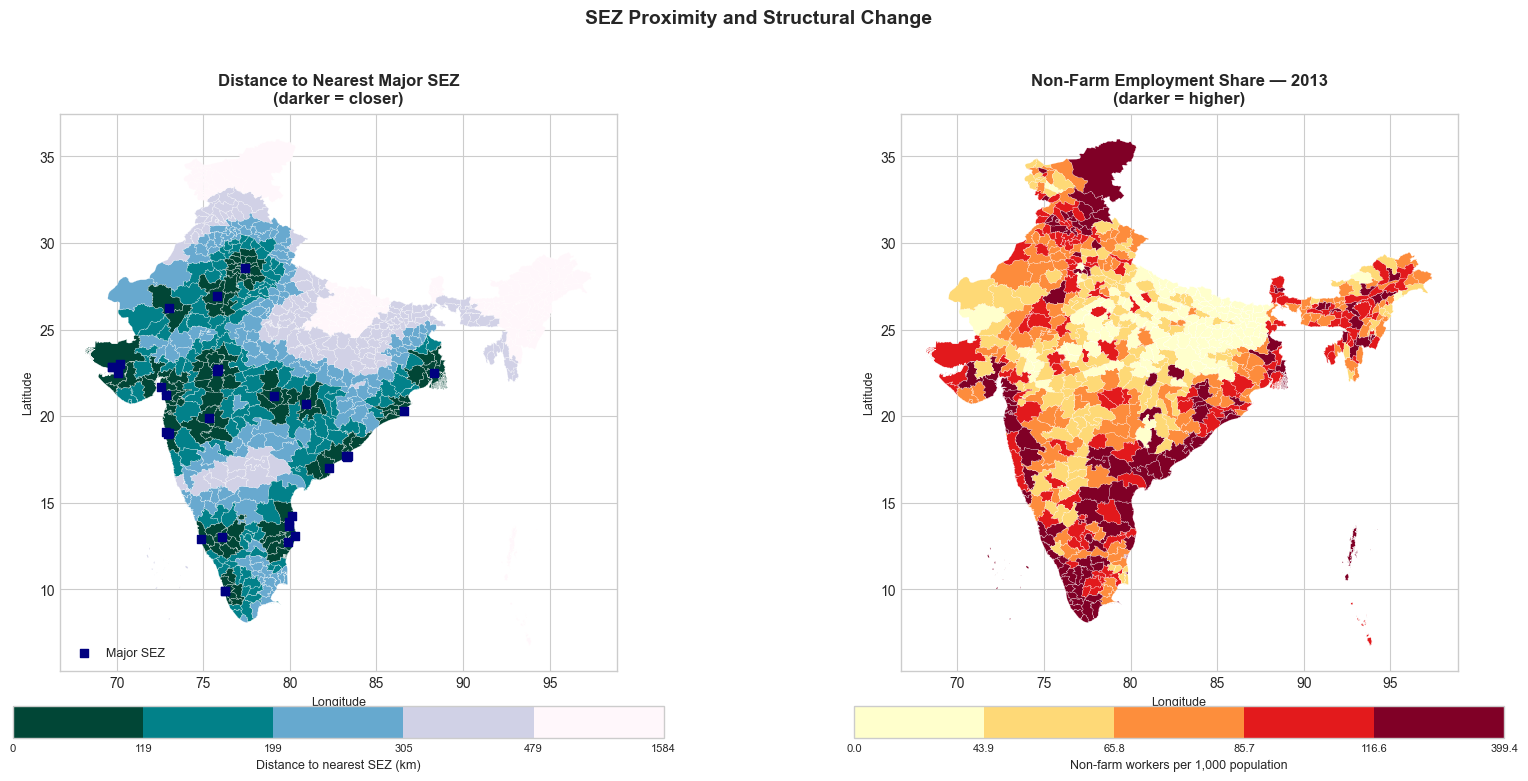

Saved: ../figures/sez_proximity_map.png


In [22]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Map 2: SEZ proximity vs non-farm share 2013
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: SEZ distance (reversed: dark = close = high exposure)
panel.plot(
    column      = 'dist_sez_km',
    ax          = axes[0],
    cmap        = 'PuBuGn_r',
    scheme      = 'quantiles',
    k           = 5,
    legend      = False,
    edgecolor   = 'white',
    linewidth   = 0.15
)

# Overlay SEZ locations
sez_gdf.plot(
    ax          = axes[0],
    color       = 'navy',
    markersize  = 30,
    marker      = 's',
    zorder      = 5,
    label       = 'Major SEZ'
)

axes[0].set_title('Distance to Nearest Major SEZ\n(darker = closer)',
                  fontsize=12, fontweight='bold', pad=8)
axes[0].set_xlabel('Longitude', fontsize=9)
axes[0].set_ylabel('Latitude', fontsize=9)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=9, loc='lower left')

breaks_sez = mapclassify.Quantiles(
    panel['dist_sez_km'].dropna(), k=5).bins
cmap_sez   = plt.cm.PuBuGn_r
norm_sez   = BoundaryNorm([0] + list(breaks_sez), cmap_sez.N)
sm_sez     = ScalarMappable(cmap=cmap_sez, norm=norm_sez)
sm_sez.set_array([])
cbar_sez   = fig.colorbar(sm_sez, ax=axes[0],
                           orientation='horizontal',
                           shrink=0.7, pad=0.05)
cbar_sez.set_label('Distance to nearest SEZ (km)', fontsize=9)
cbar_sez.ax.tick_params(labelsize=8)

# Right: non-farm share 2013 (same as before for comparison)
panel.plot(
    column      = 'nonfarm_share_13',
    ax          = axes[1],
    cmap        = 'YlOrRd',
    scheme      = 'quantiles',
    k           = 5,
    legend      = False,
    edgecolor   = 'white',
    linewidth   = 0.15
)

axes[1].set_title('Non-Farm Employment Share — 2013\n(darker = higher)',
                  fontsize=12, fontweight='bold', pad=8)
axes[1].set_xlabel('Longitude', fontsize=9)
axes[1].set_ylabel('Latitude', fontsize=9)
axes[1].set_aspect('equal')

sm_nf2   = ScalarMappable(cmap=cmap_nf, norm=norm_nf)
sm_nf2.set_array([])
cbar_nf2 = fig.colorbar(sm_nf2, ax=axes[1],
                         orientation='horizontal',
                         shrink=0.7, pad=0.05)
cbar_nf2.set_label('Non-farm workers per 1,000 population', fontsize=9)
cbar_nf2.ax.tick_params(labelsize=8)

fig.suptitle('SEZ Proximity and Structural Change',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES / 'sez_proximity_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'sez_proximity_map.png'}")

### Stage 3 — Map 2 Output: SEZ Proximity vs Non-Farm Share 2013

The SEZ proximity map shows a distinctly different spatial pattern
from the port distance map, and its relationship with structural
change is more complex.

**Where SEZ proximity aligns with structural change:**
- Gujarat and Maharashtra show both high SEZ proximity (dark teal)
  and high non-farm share (dark red) — consistent with SEZs being
  co-located with industrial activity.
- Tamil Nadu and coastal Karnataka show similar alignment.
- The northeast (pale on both maps) shows low SEZ density and low
  structural transformation.

**Where the relationship diverges — and why this is analytically
interesting:**
- **The northern plains (UP, Bihar, Rajasthan):** Moderate SEZ
  proximity (medium teal) but low non-farm share (pale on right map).
  Many of the SEZs "near" these districts are the Noida SEZ and
  Jaipur/Jodhpur SEZs — but proximity alone did not translate into
  broad district-level structural change, suggesting SEZ spillovers
  are geographically narrow.
- **The central Deccan (MP, Chhattisgarh):** Pale on both maps —
  far from SEZs and low structural change, consistent with the
  port-distance story.
- **The deep south (Kerala, southern Tamil Nadu):** High non-farm
  share despite being relatively far from our curated major SEZs —
  reflecting that Kerala's transformation is services-led and driven
  by remittances and government employment, not SEZ proximity.

**Key finding:** SEZ proximity is a weaker and more geographically
uneven predictor of structural change than port proximity. The
northern plains show a proximity-without-transformation pattern
suggesting limited SEZ spillover effects beyond the immediate zone.

Figure saved to `figures/sez_proximity_map.png`.

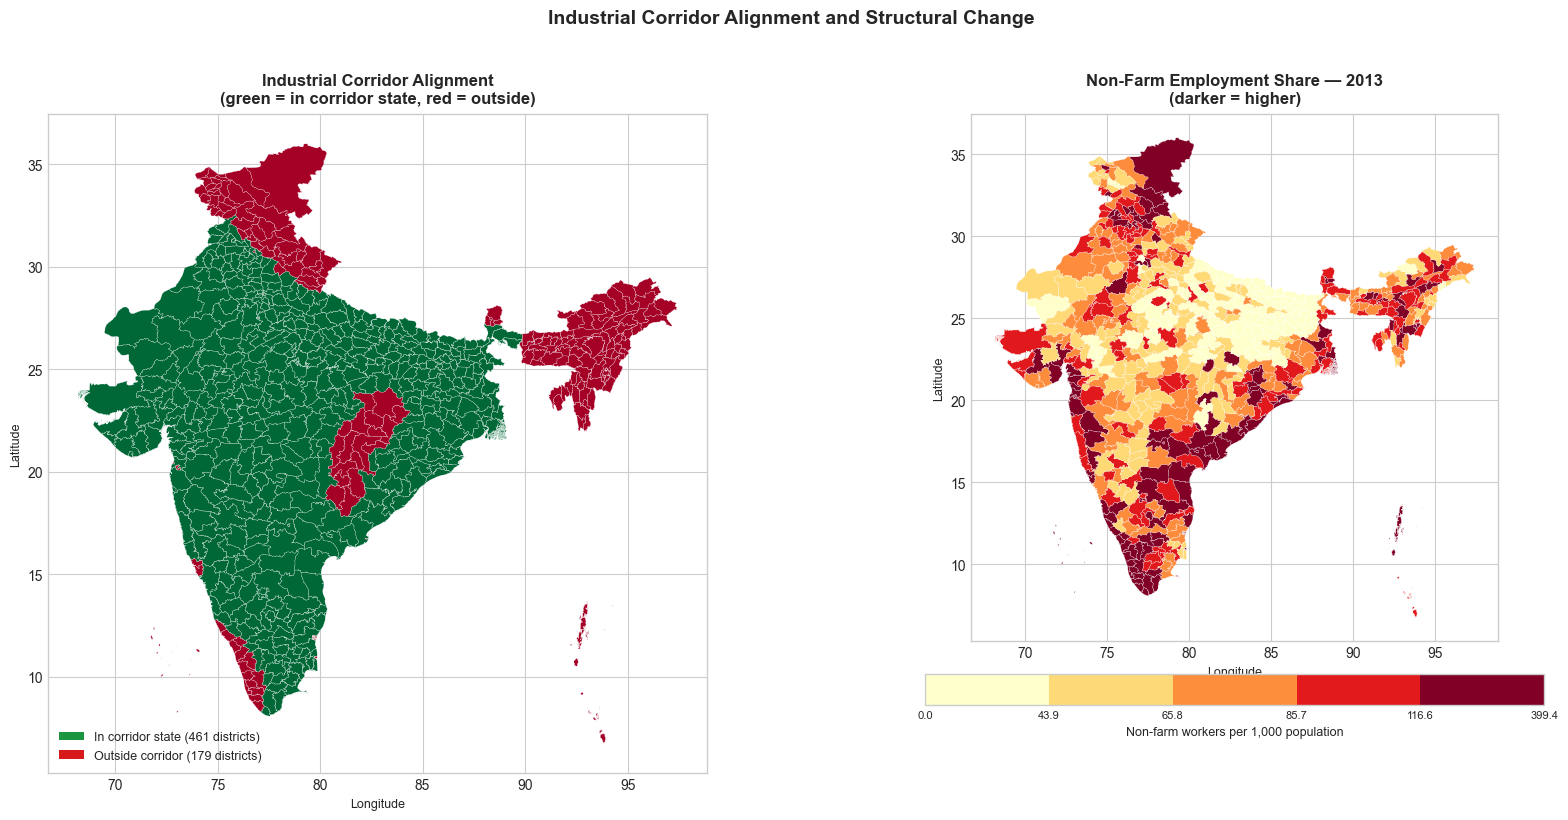

Saved: ../figures/corridor_alignment_map.png


In [23]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Map 3: Corridor alignment vs non-farm share 2013
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: corridor alignment (binary — in/out)
panel.plot(
    column      = 'any_corridor',
    ax          = axes[0],
    cmap        = 'RdYlGn',
    legend      = False,
    edgecolor   = 'white',
    linewidth   = 0.15,
    vmin        = 0,
    vmax        = 1
)

axes[0].set_title('Industrial Corridor Alignment\n'
                  '(green = in corridor state, red = outside)',
                  fontsize=12, fontweight='bold', pad=8)
axes[0].set_xlabel('Longitude', fontsize=9)
axes[0].set_ylabel('Latitude', fontsize=9)
axes[0].set_aspect('equal')

# Manual legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a9641', label='In corridor state (461 districts)'),
    Patch(facecolor='#d7191c', label='Outside corridor (179 districts)')
]
axes[0].legend(handles=legend_elements, loc='lower left', fontsize=9)

# Right: non-farm share 2013
panel.plot(
    column      = 'nonfarm_share_13',
    ax          = axes[1],
    cmap        = 'YlOrRd',
    scheme      = 'quantiles',
    k           = 5,
    legend      = False,
    edgecolor   = 'white',
    linewidth   = 0.15
)

axes[1].set_title('Non-Farm Employment Share — 2013\n(darker = higher)',
                  fontsize=12, fontweight='bold', pad=8)
axes[1].set_xlabel('Longitude', fontsize=9)
axes[1].set_ylabel('Latitude', fontsize=9)
axes[1].set_aspect('equal')

sm_nf3   = ScalarMappable(cmap=cmap_nf, norm=norm_nf)
sm_nf3.set_array([])
cbar_nf3 = fig.colorbar(sm_nf3, ax=axes[1],
                         orientation='horizontal',
                         shrink=0.7, pad=0.05)
cbar_nf3.set_label('Non-farm workers per 1,000 population', fontsize=9)
cbar_nf3.ax.tick_params(labelsize=8)

fig.suptitle('Industrial Corridor Alignment and Structural Change',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES / 'corridor_alignment_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'corridor_alignment_map.png'}")

### Stage 3 — Map 3 Output: Corridor Alignment vs Non-Farm Share 2013

The corridor alignment map covers 461 of 640 districts (72%) as
"in corridor" — a consequence of the state-level binary definition.
Because DMIC alone spans seven large states including UP, MP, and
Rajasthan, the green zone is very broad and includes many districts
with low non-farm employment share on the right map.

**Where corridor alignment predicts structural change:**
- Gujarat, Maharashtra, Tamil Nadu, Karnataka, and Andhra Pradesh
  are green on the left and dark on the right — these states benefit
  from corridor policy AND have high structural transformation.
- The spatial coincidence here is genuine: these are states where
  corridor infrastructure investments reinforced existing industrial
  advantages.

**Where the binary measure breaks down:**
- **UP, MP, Rajasthan, Bihar:** Green on the left (DMIC or AKIC
  corridor states) but pale on the right — large agrarian states
  where notional corridor membership has not translated into
  district-level structural change by 2013. The corridor policy
  was still in early implementation during our analysis window.
- **Outside-corridor states (red):** Kerala is red but shows high
  non-farm share — confirming that services-led transformation
  does not require corridor alignment. The Northeast states are
  red and pale — consistent with geographic isolation.

**Methodological reflection:** The state-level binary corridor
measure is too coarse to reveal within-state variation. A district
on the Delhi–Mumbai corridor alignment in Gujarat is categorically
identical to a remote MP district in the same DMIC state, which
is clearly wrong. A buffer-zone approach around the actual corridor
alignment polylines would be more precise — identified as a natural
extension in the README limitations section.

Figure saved to `figures/corridor_alignment_map.png`.

## Stage 4 — Proximity-Structural Change Correlation Analysis

The overlay maps in Stage 3 provide visual evidence of spatial
correlation between trade infrastructure proximity and structural
change. Stage 4 quantifies these relationships using scatter plots
and summary statistics.

We examine three relationships:
1. Port distance vs non-farm employment share 2013
2. SEZ distance vs non-farm employment share 2013
3. Corridor alignment vs non-farm employment share 2013 (box plot)

Since we are explicitly descriptive — not causal — we report
Pearson correlation coefficients and simple OLS regression lines
as visual guides only. No causal claims are made.

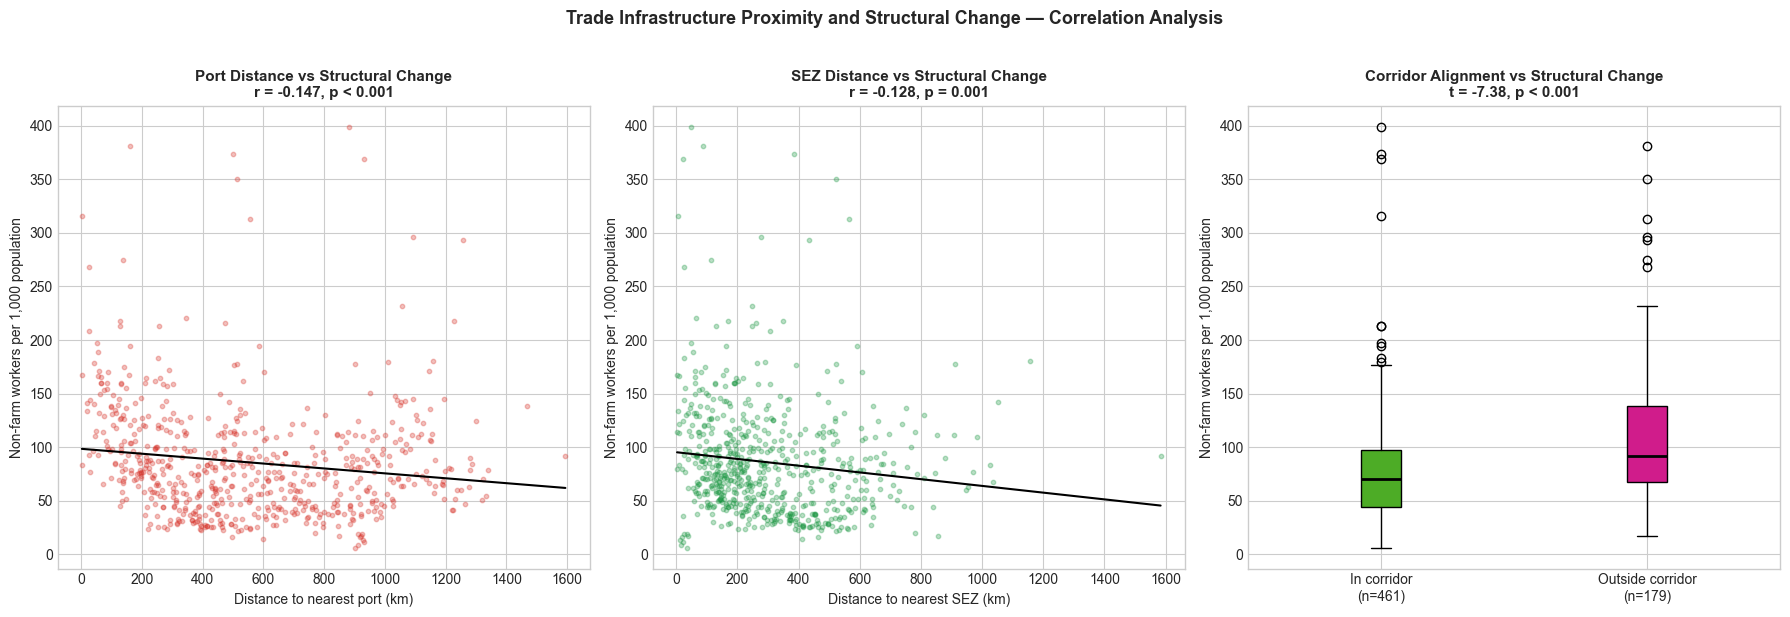

Correlation summary:
  Port distance vs nonfarm_share_13  : r=-0.147, p=0.0002
  SEZ distance vs nonfarm_share_13   : r=-0.128, p=0.0012

Corridor group means:
  In corridor  : 76.4 per 1,000
  Out corridor : 109.6 per 1,000
  t-test       : t=-7.38, p=0.0000


In [24]:
# ─────────────────────────────────────────────────────────────
# Stage 4 — Correlation analysis: proximity vs structural change
# ─────────────────────────────────────────────────────────────

from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Port distance vs non-farm share 2013 ─────────────
ax = axes[0]
x  = panel['dist_port_km'].dropna()
y  = panel.loc[x.index, 'nonfarm_share_13']

# Remove rows where either is NaN
mask = x.notna() & y.notna()
x, y = x[mask], y[mask]

r, p = stats.pearsonr(x, y)

ax.scatter(x, y, alpha=0.3, s=10, color='#d73027')
# OLS regression line
m, b  = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)

ax.set_xlabel('Distance to nearest port (km)', fontsize=10)
ax.set_ylabel('Non-farm workers per 1,000 population', fontsize=10)
ax.set_title(f'Port Distance vs Structural Change\nr = {r:.3f}, '
             f'p {"< 0.001" if p < 0.001 else f"= {p:.3f}"}',
             fontsize=11, fontweight='bold')

# ── Plot 2: SEZ distance vs non-farm share 2013 ──────────────
ax = axes[1]
x2 = panel['dist_sez_km']
y2 = panel['nonfarm_share_13']
mask2 = x2.notna() & y2.notna()
x2, y2 = x2[mask2], y2[mask2]

r2, p2 = stats.pearsonr(x2, y2)

ax.scatter(x2, y2, alpha=0.3, s=10, color='#1a9641')
m2, b2  = np.polyfit(x2, y2, 1)
x_line2 = np.linspace(x2.min(), x2.max(), 100)
ax.plot(x_line2, m2 * x_line2 + b2, color='black', linewidth=1.5)

ax.set_xlabel('Distance to nearest SEZ (km)', fontsize=10)
ax.set_ylabel('Non-farm workers per 1,000 population', fontsize=10)
ax.set_title(f'SEZ Distance vs Structural Change\nr = {r2:.3f}, '
             f'p {"< 0.001" if p2 < 0.001 else f"= {p2:.3f}"}',
             fontsize=11, fontweight='bold')

# ── Plot 3: Corridor alignment box plot ──────────────────────
ax = axes[2]
in_corridor  = panel.loc[panel['any_corridor'] == 1, 
                          'nonfarm_share_13'].dropna()
out_corridor = panel.loc[panel['any_corridor'] == 0, 
                          'nonfarm_share_13'].dropna()

bp = ax.boxplot(
    [in_corridor, out_corridor],
    labels    = ['In corridor\n(n={})'.format(len(in_corridor)),
                 'Outside corridor\n(n={})'.format(len(out_corridor))],
    patch_artist = True,
    medianprops  = {'color': 'black', 'linewidth': 2}
)
bp['boxes'][0].set_facecolor('#4dac26')
bp['boxes'][1].set_facecolor('#d01c8b')

# T-test
t, pt = stats.ttest_ind(in_corridor, out_corridor)
ax.set_ylabel('Non-farm workers per 1,000 population', fontsize=10)
ax.set_title(f'Corridor Alignment vs Structural Change\n'
             f't = {t:.2f}, p {"< 0.001" if pt < 0.001 else f"= {pt:.3f}"}',
             fontsize=11, fontweight='bold')

fig.suptitle('Trade Infrastructure Proximity and Structural Change — '
             'Correlation Analysis',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES / 'proximity_vs_structural_change.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("Correlation summary:")
print(f"  Port distance vs nonfarm_share_13  : r={r:.3f}, p={p:.4f}")
print(f"  SEZ distance vs nonfarm_share_13   : r={r2:.3f}, p={p2:.4f}")
print(f"\nCorridor group means:")
print(f"  In corridor  : {in_corridor.mean():.1f} per 1,000")
print(f"  Out corridor : {out_corridor.mean():.1f} per 1,000")
print(f"  t-test       : t={t:.2f}, p={pt:.4f}")

### Stage 4 — Correlation Analysis Output

**Port distance vs non-farm share (r = -0.147, p < 0.001):**
The negative correlation confirms the expected direction — districts
closer to ports have higher non-farm employment share. However, the
magnitude is modest. r = -0.147 means port distance explains only
about 2% of the variance in non-farm share across districts. The
scatter plot shows enormous dispersion around the regression line —
many districts far from ports have high non-farm share (northern
government-employment districts) and many close to ports have low
share (coastal agrarian districts in Odisha). Port proximity is a
statistically significant but weak predictor of structural change
at the district level.

**SEZ distance vs non-farm share (r = -0.128, p = 0.001):**
Similarly signed but slightly weaker than port distance. The expected
negative relationship holds — proximity to major SEZs correlates with
higher non-farm employment — but again the magnitude is modest. The
scatter shows even more dispersion than the port distance plot,
consistent with SEZ spillovers being geographically narrow and not
diffusing broadly to surrounding districts.

**Corridor alignment vs non-farm share (t = -7.38, p < 0.001):**
This result appears counterintuitive at first — districts *outside*
corridor states have a higher mean non-farm share (109.6) than those
*inside* corridor states (76.4). The t-statistic is large and highly
significant, but the direction is reversed from what corridor policy
would predict.

This is not a paradox — it reflects the composition of the
outside-corridor group. The 179 districts outside all corridor
states include Kerala (high non-farm share, services-led), the
Northeastern hill states (high government employment share), and
Himachal Pradesh and Uttarakhand (tourism and government). Meanwhile,
the 461 corridor districts include large swaths of UP, Bihar, MP,
and Rajasthan — India's most agrarian and populous states — which
pull the corridor mean down substantially.

This is a classic ecological confounding problem: corridor states
contain more low-income agrarian districts simply because they are
larger and more populous, not because corridors suppress structural
change. The binary state-level corridor measure is too coarse to
isolate the effect of corridor policy from state-level composition.

**Overall finding:** All three proximity measures show statistically
significant associations with structural change in the expected
direction (or explicable direction for corridors), but effect sizes
are small. Trade infrastructure proximity is one factor among many
shaping India's structural transformation — state-level policies,
agglomeration economies, historical industrial base, and geography
jointly determine outcomes. This is consistent with the broader
empirical literature on SEZ and corridor effects in developing
countries.

Figure saved to `figures/proximity_vs_structural_change.png`.

## Notebook 3 — Summary

This notebook constructed three district-level trade exposure proxy
measures and examined their spatial correlation with structural change
outcomes from Notebook 2.

**Infrastructure data assembled:**
- 12 major ports (hardcoded coordinates, Indian Ports Association)
- 32 major operational SEZs (curated list; full MoC PDF parsing
  attempted but yielded incomplete results due to inconsistent
  formatting — documented transparently)
- 5 industrial corridors (state-level binary, DPIIT notifications)

**Distance measures computed:**
- Port distance: mean 553 km, range 2–1,594 km
- SEZ distance: mean 302 km, range 3–1,584 km
- Corridor alignment: 461 of 640 districts in at least one corridor

**Key analytical findings:**
1. Port and SEZ proximity are negatively correlated with non-farm
   share — closer districts show higher structural transformation —
   but effect sizes are modest (r ≈ -0.13 to -0.15). Enormous
   within-distance-band variation indicates proximity is one factor
   among many.
2. The corridor alignment result (outside-corridor districts showing
   higher mean non-farm share) reflects ecological confounding — large
   agrarian states dominate the corridor group — not a real negative
   effect of corridor policy. The state-level binary measure is too
   coarse for within-corridor analysis.
3. Together, the three maps and correlation analysis suggest that
   trade infrastructure proximity shaped the broad contours of
   structural change geography (coastal vs interior) but does not
   explain district-level variation within regions.

**Full panel saved:** `data/processed/districts_full_panel.gpkg`
(640 districts × 43 columns)

**Ready for Notebook 4:** Publication-quality visualisation — polished
multi-panel figures suitable for a working paper or research
presentation.